Imports done ✅
Shape after cleaning: (7032, 20)
Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train: 5625 | Test: 1407
Preprocessor built ✅
All 3 pipelines built ✅

📊 Logistic Regression
   Accuracy: 0.8038
   F1 Score: 0.6080
   ROC-AUC:  0.7299

📊 Random Forest
   Accuracy: 0.7875
   F1 Score: 0.5477
   ROC-AUC:  0.6907

📊 XGBoost
   Accuracy: 0.7690
   F1 Score: 0.5480
   ROC-AUC:  0.6917

📊 Summary Table:
              Model  Accuracy  F1 Score  ROC-AUC
Logistic Regression  0.803838  0.607955 0.729949
      Random Forest  0.787491  0.547655 0.690672
            XGBoost  0.769012  0.547983 0.691733


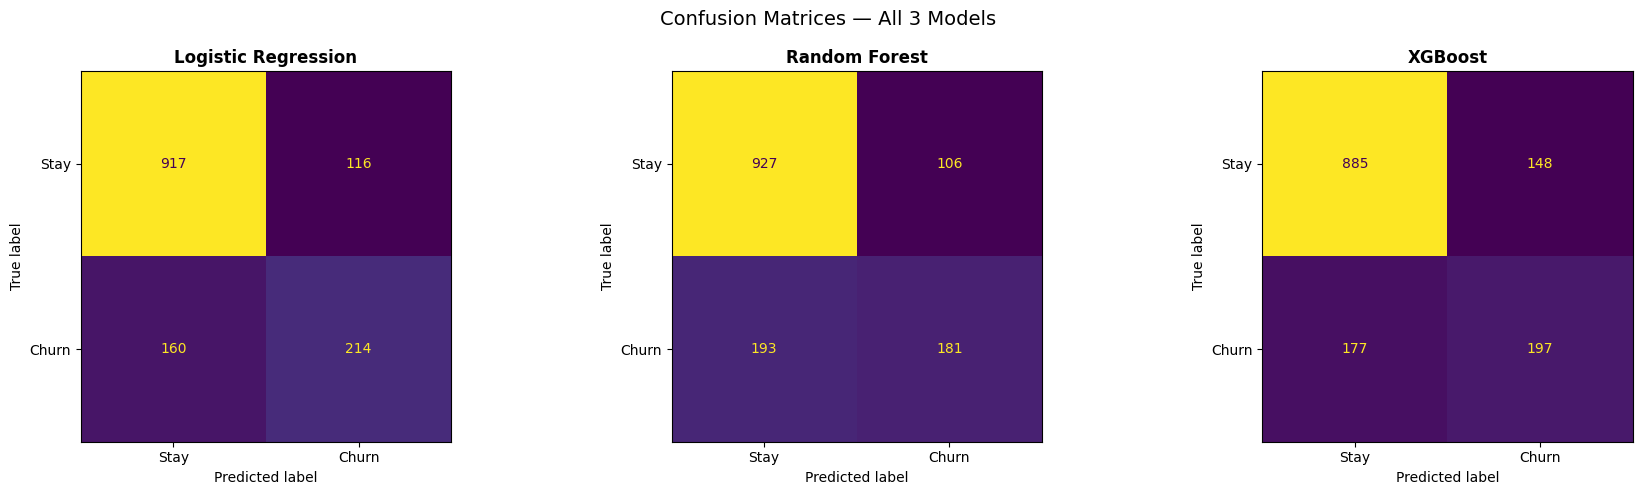

Best model: Logistic Regression
Pipeline saved ✅
Load verified ✅ | Accuracy: 0.8038379530916845

📊 Logistic Regression:
              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


📊 Random Forest:
              precision    recall  f1-score   support

        Stay       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407


📊 XGBoost:
              precision    recall  f1-score   support

        Stay       0.83      0.86      0.84      1033
       Churn       0.57      0.53      0.55       374

    accuracy                    

In [2]:
# ============================================================
# DAY 8 — End-to-End ML Pipelines
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import joblib
print("Imports done ✅")

# ── Block 2: Load & Clean Data ────────────────────────────
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print("Shape after cleaning:", df.shape)
print("Churn distribution:\n", df['Churn'].value_counts())

# ── Block 3: Identify Columns & Split ─────────────────────
X = df.drop('Churn', axis=1)
y = df['Churn']
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

# ── Block 4: Build ColumnTransformer ─────────────────────
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)])
print("Preprocessor built ✅")

# ── Block 5: Build 3 Full Pipelines ──────────────────────
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42,
                                  eval_metric='logloss', verbosity=0))])
print("All 3 pipelines built ✅")

# ── Block 6: Train & Evaluate All Models ─────────────────
models = {'Logistic Regression': pipe_lr,
          'Random Forest': pipe_rf, 'XGBoost': pipe_xgb}
results = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results.append({'Model': name,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'F1 Score': f1_score(y_test, y_pred),
                    'ROC-AUC': roc_auc_score(y_test, y_pred)})
    print(f"\n📊 {name}")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"   ROC-AUC:  {roc_auc_score(y_test, y_pred):.4f}")
results_df = pd.DataFrame(results)
print("\n📊 Summary Table:")
print(results_df.to_string(index=False))

# ── Block 7: Confusion Matrices ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipeline) in zip(axes, models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Stay', 'Churn'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrices — All 3 Models', fontsize=14)
plt.tight_layout()
plt.show()

# ── Block 8: Save Best Pipeline ───────────────────────────
best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
best_pipeline = models[best_model_name]
joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')
print(f"Best model: {best_model_name}")
print("Pipeline saved ✅")
loaded = joblib.load('best_churn_pipeline.pkl')
print("Load verified ✅ | Accuracy:",
      accuracy_score(y_test, loaded.predict(X_test)))

# ── Block 9: Detailed Classification Reports ──────────────
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    print(f"\n📊 {name}:")
    print(classification_report(y_test, y_pred,
                                 target_names=['Stay', 'Churn']))

Imports done ✅
Shape: (569, 30)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


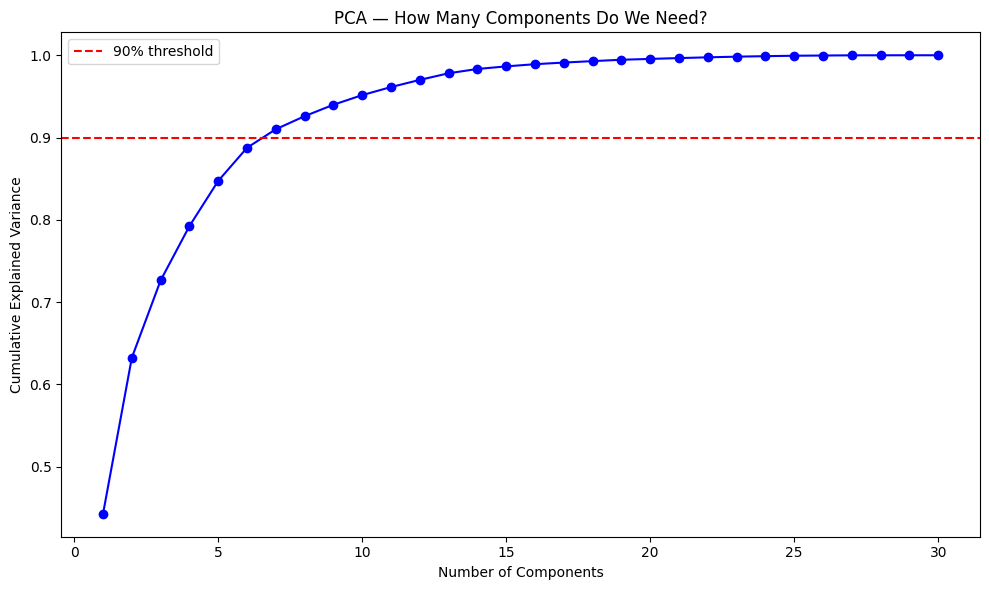

Components needed for 90% variance: 7
Reduction: 30 → 7 features

📊 Without PCA:
   Accuracy: 0.9825
   F1 Score: 0.9861
   ROC-AUC:  0.9812

📊 With PCA:
   Accuracy: 0.9474
   F1 Score: 0.9577
   ROC-AUC:  0.9484


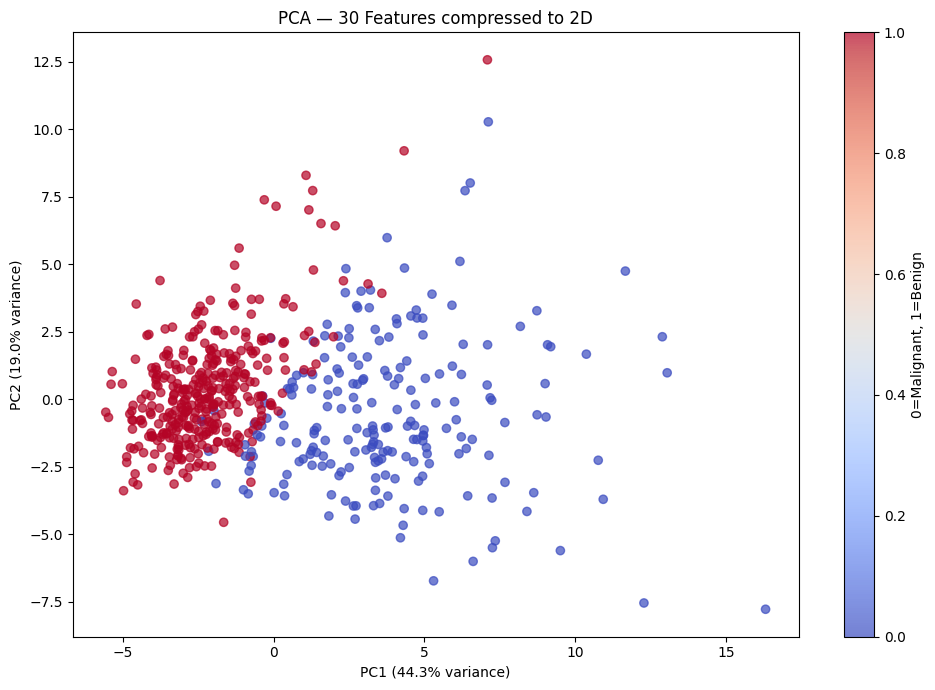


Churn dataset — Components for 90% variance: 3 out of 4


In [1]:
# ============================================================
# DAY 9 — Dimensionality Reduction & PCA
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.datasets import load_breast_cancer
print("Imports done ✅")

# ── Block 2: Load Data ────────────────────────────────────
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)
print("Shape:", X.shape)
print("Features:", X.columns.tolist())

# ── Block 3: Explained Variance Plot ─────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance, marker='o', color='blue')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — How Many Components Do We Need?')
plt.legend()
plt.tight_layout()
plt.show()
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Reduction: {X.shape[1]} → {n_components_90} features")

# ── Block 4: PCA Inside Pipeline ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
pipe_with_pca = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
pipe_without_pca = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
for name, pipe in [("Without PCA", pipe_without_pca),
                    ("With PCA", pipe_with_pca)]:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"\n📊 {name}:")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"   ROC-AUC:  {roc_auc_score(y_test, y_pred):.4f}")

# ── Block 5: 2D Visualisation ─────────────────────────────
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='0=Malignant, 1=Benign')
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA — 30 Features compressed to 2D')
plt.tight_layout()
plt.show()

# ── Block 6: PCA on Churn Dataset ────────────────────────
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
X_churn = df.select_dtypes(include=['int64','float64']).drop(
    'Churn', axis=1, errors='ignore')
y_churn = df['Churn']
X_churn_scaled = StandardScaler().fit_transform(X_churn)
pca_churn = PCA()
pca_churn.fit(X_churn_scaled)
cumvar = np.cumsum(pca_churn.explained_variance_ratio_)
n_comp = np.argmax(cumvar >= 0.90) + 1
print(f"\nChurn dataset — Components for 90% variance: {n_comp} out of {X_churn.shape[1]}")